# Does stratification differ between AEs and CEs, and does it explain tilt magnitude?

This notebook tests two related hypotheses without assuming either result:

1. **CEs are more strongly stratified than AEs.**
2. **More strongly stratified eddies have larger coherent tilt magnitudes (`TiltDis`).**

The primary stratification measures are the eddy-core mean $N^2$ over 0–200 m and 0–500 m. The shallower measure should be more sensitive to cyclone/anticyclone thermocline displacement; the 0–500 m mean is a depth-integrated sensitivity test. The analysis reports raw eddy-equal contrasts and adjusted daily models controlling for latitude, season, region, radius, and bathymetry. It also separates **between-eddy** differences from **within-eddy** day-to-day covariation.

`TiltDis` is used exactly as derived in the tilt dataset. No 5-km directional threshold is applied: truncating small values would bias a magnitude comparison.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import mannwhitneyu, spearmanr
import statsmodels.formula.api as smf
import statsmodels.api as sm

HERE = Path.cwd().resolve()
ANALYSIS_ROOT = next((p for p in (HERE, *HERE.parents) if (p / 'seacofs_tilt_tools.py').exists()), None)
if ANALYSIS_ROOT is None:
    raise FileNotFoundError('Launch from seacofs_eddy_tilt_analysis or one of its subfolders.')
MECHANISM_ROOT = ANALYSIS_ROOT / 'tilt_mechanisms'
for path in (ANALYSIS_ROOT, MECHANISM_ROOT):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

import seacofs_tilt_tools as tilt
import mechanism_tools as mech

sns.set_theme(style='ticks', context='notebook')
PALETTE = {'AE': '#d95f02', 'CE': '#1b9e77'}
N2_CACHE = mech.DEFAULT_N2_CACHE_PATH
MIN_CORE_VALID_FRACTION = 0.80
N_BOOT = 5000
RNG = np.random.default_rng(5297792)

## Load and audit the matched sample

The cache contains the same contour-based core averages used elsewhere in this workflow. Coverage QC is applied separately at each integration depth.

In [2]:
paths = tilt.Paths()
grid = tilt.load_grid(paths.grid, paths.z_r)
df, _ = tilt.load_tilt_tables(paths)
df = mech.require_tilt_measurements(df)
df = tilt.add_region_labels(df, grid)
if 'Date' in df.columns:
    df = tilt.add_season(df)
else:
    df['Season'] = 'Unavailable'

n2 = mech.load_stratification_cache(N2_CACHE)
data = mech.merge_one_to_one_or_many_to_one(df, n2)
for depth in (200, 500):
    data[f'N2_{depth}m_s2'] = data[f'N2_{depth}m_core_s2']
    coverage = f'N2_{depth}m_core_valid_fraction'
    if coverage in data:
        data.loc[data[coverage] < MIN_CORE_VALID_FRACTION, f'N2_{depth}m_s2'] = np.nan

data = data.loc[data['Cyc'].isin(['AE', 'CE']) & data['TiltDis'].ge(0)].copy()
data['h'] = grid.h[data.ic, data.jc]
for col in ('Rc', 'h'):
    data[f'z_{col}'] = (data[col] - data[col].mean()) / data[col].std()
data['log_tilt'] = np.log1p(data['TiltDis'])

audit = (data.groupby('Cyc').agg(rows=('Eddy', 'size'), eddies=('Eddy', 'nunique'),
                                    tilt_available=('TiltDis', 'count'),
                                    n2_200_available=('N2_200m_s2', 'count'),
                                    n2_500_available=('N2_500m_s2', 'count')))
display(audit)
print(f'Cache: {N2_CACHE}')

,rows,eddies,tilt_available,n2_200_available,n2_500_available
Cyc,,,,,
AE,53607,1422,53607,53607,53607
CE,52014,1531,52014,52014,52014


Cache: /srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset/tilt_mechanisms/n2_eddy_day_v4_potential_density_core.parquet


## 1. Raw AE–CE contrasts (one value per eddy)

Daily observations from the same eddy are not independent. The descriptive comparison therefore uses each eddy's median value. Bootstrap confidence intervals resample eddies, not days. Positive CE–AE values mean larger values in CEs; negative AE–CE tilt values would contradict the reported larger AE tilt.

,outcome,contrast,median_difference,CI_2.5%,CI_97.5%,Mann_Whitney_p,AE_median,CE_median
0,TiltDis,AE - CE,5.368619,4.019718,6.534239,7.771246e-28,22.342611,16.973992
1,N2_200m_1e5,CE - AE,1.938348,1.558733,2.456597,4.363278e-54,2.844200,4.782548
2,N2_500m_1e5,CE - AE,0.298835,0.141656,0.456156,2.337905e-08,2.970358,3.269193


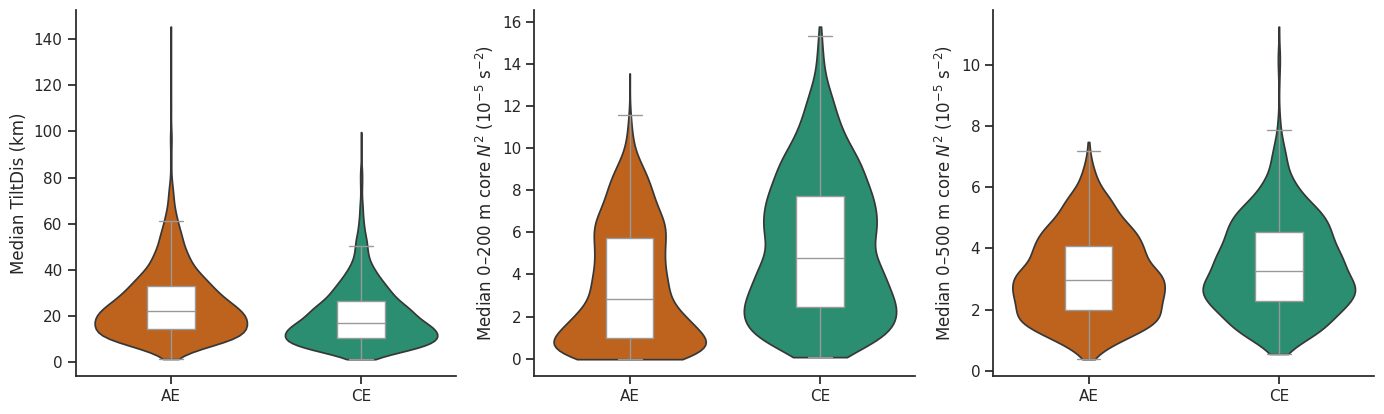

In [3]:
eddy = (data.groupby(['Cyc', 'Eddy'], as_index=False)
        .agg(TiltDis=('TiltDis', 'median'), N2_200m_s2=('N2_200m_s2', 'median'),
             N2_500m_s2=('N2_500m_s2', 'median'), lat=('lat', 'median'),
             Rc=('Rc', 'median'), h=('h', 'median')))
eddy['N2_200m_1e5'] = eddy['N2_200m_s2'] * 1e5
eddy['N2_500m_1e5'] = eddy['N2_500m_s2'] * 1e5

def bootstrap_median_difference(frame, value, first, second, n_boot=N_BOOT):
    a = frame.loc[frame.Cyc.eq(first), value].dropna().to_numpy()
    b = frame.loc[frame.Cyc.eq(second), value].dropna().to_numpy()
    observed = np.median(a) - np.median(b)
    boot = np.array([np.median(RNG.choice(a, len(a), replace=True)) -
                     np.median(RNG.choice(b, len(b), replace=True)) for _ in range(n_boot)])
    return observed, *np.quantile(boot, [0.025, 0.975])

rows = []
for value, contrast in [('TiltDis', ('AE', 'CE')), ('N2_200m_1e5', ('CE', 'AE')),
                        ('N2_500m_1e5', ('CE', 'AE'))]:
    a, b = contrast
    delta, lo, hi = bootstrap_median_difference(eddy, value, a, b)
    x = eddy.loc[eddy.Cyc.eq(a), value].dropna()
    y = eddy.loc[eddy.Cyc.eq(b), value].dropna()
    rows.append({'outcome': value, 'contrast': f'{a} - {b}', 'median_difference': delta,
                 'CI_2.5%': lo, 'CI_97.5%': hi,
                 'Mann_Whitney_p': mannwhitneyu(x, y, alternative='two-sided').pvalue,
                 f'{a}_median': x.median(), f'{b}_median': y.median()})
raw_contrasts = pd.DataFrame(rows)
display(raw_contrasts)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.3))
for ax, value, ylabel in zip(axes, ['TiltDis', 'N2_200m_1e5', 'N2_500m_1e5'],
                              ['Median TiltDis (km)', r'Median 0–200 m core $N^2$ ($10^{-5}$ s$^{-2}$)',
                               r'Median 0–500 m core $N^2$ ($10^{-5}$ s$^{-2}$)']):
    sns.violinplot(data=eddy, x='Cyc', y=value, hue='Cyc', palette=PALETTE, inner=None, cut=0, legend=False, ax=ax)
    sns.boxplot(data=eddy, x='Cyc', y=value, width=.25, showfliers=False, color='white', ax=ax)
    ax.set(xlabel='', ylabel=ylabel)
sns.despine(); plt.tight_layout()

## 2. Are the polarity contrasts independent of sampling context?

These population-averaged GEE models retain daily information while clustering repeated observations by eddy. The `Cyc[T.CE]` coefficient is the adjusted CE–AE difference. Stratification outcomes are expressed in $10^{-5}$ s$^{-2}$; tilt is log-transformed because its distribution is right-skewed.

In [4]:
data['N2_200m_1e5'] = data['N2_200m_s2'] * 1e5
data['N2_500m_1e5'] = data['N2_500m_s2'] * 1e5
controls = ['bs(lat, df=4)', 'z_Rc', 'z_h', 'C(Region)']
if data['Season'].nunique(dropna=True) > 1:
    controls.append('C(Season)')
rhs = 'C(Cyc, Treatment(reference="AE")) + ' + ' + '.join(controls)

def fit_gee(outcome):
    cols = [outcome, 'Eddy', 'Cyc', 'lat', 'z_Rc', 'z_h', 'Region', 'Season']
    model_data = data[cols].replace([np.inf, -np.inf], np.nan).dropna()
    return smf.gee(f'{outcome} ~ {rhs}', groups='Eddy', data=model_data,
                   family=sm.families.Gaussian()).fit()

adjusted_models = {outcome: fit_gee(outcome) for outcome in ['log_tilt', 'N2_200m_1e5', 'N2_500m_1e5']}
term = 'C(Cyc, Treatment(reference="AE"))[T.CE]'
adjusted_table = []
for outcome, fit in adjusted_models.items():
    ci = fit.conf_int().loc[term]
    adjusted_table.append({'outcome': outcome, 'adjusted_CE_minus_AE': fit.params[term],
                           'CI_2.5%': ci.iloc[0], 'CI_97.5%': ci.iloc[1], 'p': fit.pvalues[term],
                           'daily_rows': int(fit.nobs)})
display(pd.DataFrame(adjusted_table))

,outcome,adjusted_CE_minus_AE,CI_2.5%,CI_97.5%,p,daily_rows
0,log_tilt,-0.259103,-0.298476,-0.219730,4.614826e-38,105621
1,N2_200m_1e5,1.703321,1.581629,1.825012,1.086983e-165,105621
2,N2_500m_1e5,0.178402,0.129304,0.227500,1.065631e-12,105621


## 3. Does stronger stratification accompany larger tilt?

The scatterplots use one point per eddy and show polarity-specific LOWESS curves. Spearman correlations describe the unadjusted monotonic association. They are descriptive: latitude, eddy size, depth, season, and region can generate a correlation even if stratification itself is not the relevant mechanism.

,depth,polarity,eddies,Spearman_rho,p
0,0–200 m,AE,1422,0.168410,1.650894e-10
1,0–200 m,CE,1531,0.000519,9.838190e-01
2,0–500 m,AE,1422,0.270850,2.490120e-25
3,0–500 m,CE,1531,0.132432,1.987499e-07


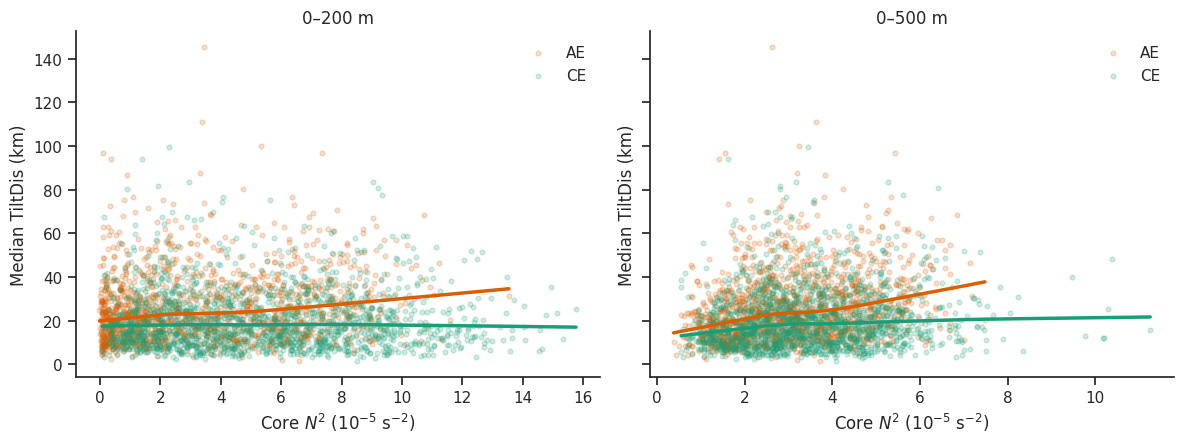

In [5]:
correlation_rows = []
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), sharey=True)
for ax, n2_col, title in zip(axes, ['N2_200m_1e5', 'N2_500m_1e5'], ['0–200 m', '0–500 m']):
    for cyc in ('AE', 'CE'):
        part = eddy.loc[eddy.Cyc.eq(cyc), [n2_col, 'TiltDis']].dropna()
        rho, p = spearmanr(part[n2_col], part['TiltDis'])
        correlation_rows.append({'depth': title, 'polarity': cyc, 'eddies': len(part), 'Spearman_rho': rho, 'p': p})
        sns.regplot(data=part, x=n2_col, y='TiltDis', lowess=True, scatter_kws={'s': 12, 'alpha': .20},
                    line_kws={'lw': 2.5}, color=PALETTE[cyc], label=cyc, ax=ax)
    ax.set(title=title, xlabel=r'Core $N^2$ ($10^{-5}$ s$^{-2}$)', ylabel='Median TiltDis (km)')
    ax.legend(frameon=False)
display(pd.DataFrame(correlation_rows))
sns.despine(); plt.tight_layout()

## 4. Separate between-eddy and within-eddy effects

This is the key mechanistic test. For each depth, $N^2$ is decomposed into:

- **between-eddy:** the eddy's time-mean stratification (do generally more stratified eddies tilt more?), and
- **within-eddy:** the day's anomaly from that eddy mean (does an eddy tilt more on its more-stratified days?).

Both components are standardised to one standard deviation, and interactions allow AE and CE slopes to differ. A positive raw correlation without a positive adjusted between- or within-eddy coefficient should not be interpreted as evidence that stratification increases tilt.

,depth_m,component,polarity,log_tilt_per_SD_N2,CI_2.5%,CI_97.5%
0,200,within,AE,0.046525,0.023583,0.069468
1,200,within,CE,-0.004138,-0.024431,0.016155
2,200,between,AE,0.084777,0.039930,0.129624
3,200,between,CE,-0.049069,-0.082437,-0.015702
4,500,within,AE,0.063775,0.036259,0.091290
5,500,within,CE,0.008496,-0.009035,0.026026
6,500,between,AE,0.094977,0.050669,0.139285
7,500,between,CE,-0.022682,-0.056735,0.011371


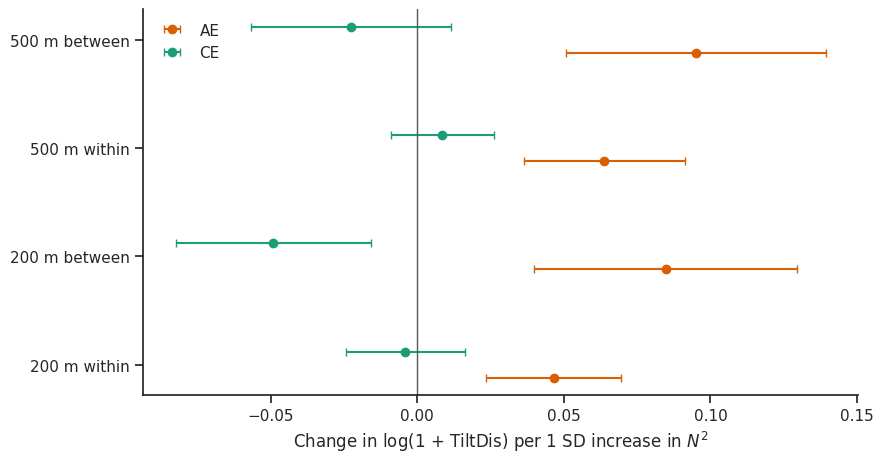

In [6]:
wb = mech.standardise_within_between(data, ['N2_200m_1e5', 'N2_500m_1e5'])
for depth in (200, 500):
    for component in ('within', 'between'):
        col = f'N2_{depth}m_1e5_{component}'
        wb[f'z_{col}'] = wb[col] / wb[col].std()

effect_rows = []
within_between_models = {}
for depth in (200, 500):
    within = f'z_N2_{depth}m_1e5_within'
    between = f'z_N2_{depth}m_1e5_between'
    formula = (f'log_tilt ~ ({within} + {between}) * C(Cyc, Treatment(reference="AE")) + ' +
               ' + '.join(controls))
    needed = ['log_tilt', 'Eddy', 'Cyc', 'lat', 'z_Rc', 'z_h', 'Region', 'Season', within, between]
    model_data = wb[needed].replace([np.inf, -np.inf], np.nan).dropna()
    fit = smf.gee(formula, groups='Eddy', data=model_data, family=sm.families.Gaussian()).fit()
    within_between_models[depth] = fit
    for component, base in [('within', within), ('between', between)]:
        interaction = base + ':C(Cyc, Treatment(reference="AE"))[T.CE]'
        for cyc in ('AE', 'CE'):
            if cyc == 'AE':
                estimate = fit.params[base]
                se = fit.bse[base]
            else:
                estimate = fit.params[base] + fit.params[interaction]
                cov = fit.cov_params()
                se = np.sqrt(cov.loc[base, base] + cov.loc[interaction, interaction] + 2 * cov.loc[base, interaction])
            effect_rows.append({'depth_m': depth, 'component': component, 'polarity': cyc,
                                'log_tilt_per_SD_N2': estimate, 'CI_2.5%': estimate - 1.96*se,
                                'CI_97.5%': estimate + 1.96*se})
effects = pd.DataFrame(effect_rows)
display(effects)

fig, ax = plt.subplots(figsize=(9, 4.8))
plot = effects.copy()
plot['label'] = plot['depth_m'].astype(str) + ' m ' + plot['component']
positions = {label: i for i, label in enumerate(plot['label'].unique())}
for cyc, offset in [('AE', -.12), ('CE', .12)]:
    part = plot[plot.polarity.eq(cyc)]
    y = np.array([positions[x] for x in part.label]) + offset
    ax.errorbar(part.log_tilt_per_SD_N2, y,
                xerr=[part.log_tilt_per_SD_N2-part['CI_2.5%'], part['CI_97.5%']-part.log_tilt_per_SD_N2],
                fmt='o', color=PALETTE[cyc], capsize=3, label=cyc)
ax.axvline(0, color='0.35', lw=1)
ax.set(yticks=list(positions.values()), yticklabels=list(positions), xlabel='Change in log(1 + TiltDis) per 1 SD increase in $N^2$', ylabel='')
ax.legend(frameon=False); sns.despine(); plt.tight_layout()

## 5. Latitude-adjusted low/medium/high stratification groups

For communication, eddies are placed into polarity-specific tertiles after removing a quadratic latitude trend. This prevents the equatorward background $N^2$ gradient from defining the groups. The continuous models above remain the primary inference; tertiles are a visual summary.

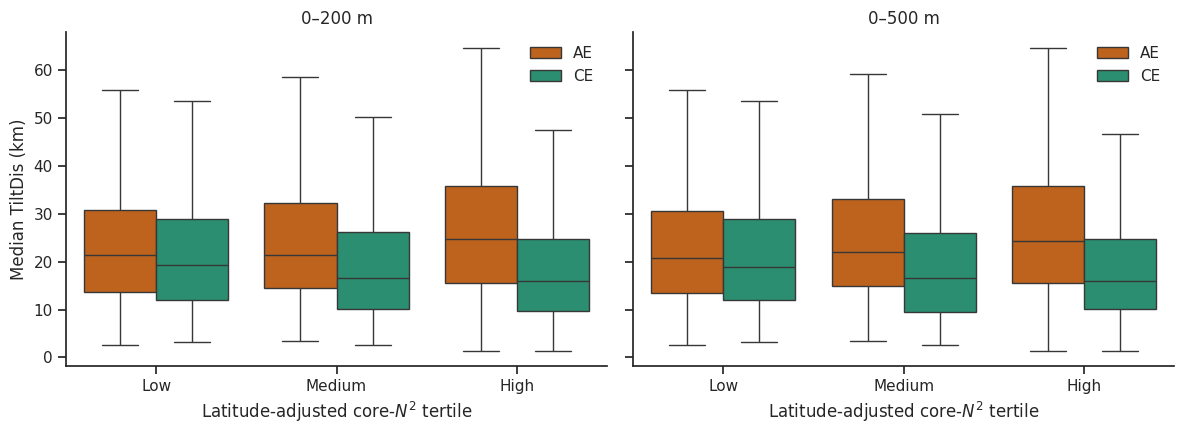

In [7]:
classified = data.copy()
for depth in (200, 500):
    classified = mech.add_eddy_stratification_categories(
        classified, f'N2_{depth}m_s2', class_col=f'N2Class{depth}Adjusted', latitude_col='lat')
class_eddy = (classified.groupby(['Cyc', 'Eddy'], as_index=False)
              .agg(TiltDis=('TiltDis', 'median'),
                   N2Class200Adjusted=('N2Class200Adjusted', 'first'),
                   N2Class500Adjusted=('N2Class500Adjusted', 'first')))
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for ax, depth in zip(axes, (200, 500)):
    cls = f'N2Class{depth}Adjusted'
    sns.boxplot(data=class_eddy, x=cls, y='TiltDis', hue='Cyc', palette=PALETTE,
                order=['Low', 'Medium', 'High'], showfliers=False, ax=ax)
    ax.set(title=f'0–{depth} m', xlabel='Latitude-adjusted core-$N^2$ tertile', ylabel='Median TiltDis (km)')
    ax.legend(frameon=False, title='')
sns.despine(); plt.tight_layout()

## 6. Sensitivity to the definition of stratification

A fixed-depth mean can change because an eddy lifts or depresses the pycnocline. The corrected cache therefore supplies complementary diagnostics: fixed-depth integrals and maxima, a pycnocline-following ±50 m mean and maximum, pycnocline depth, and a 0.03 kg m⁻³ density-threshold mixed-layer depth. The table uses one median per eddy. The adjusted models standardise every diagnostic, so CE–AE coefficients are comparable in SD units. For pycnocline and mixed-layer depths, positive means deeper rather than more strongly stratified.

,metric,AE_median,CE_median,CE_minus_AE_in_SD,AE_eddies,CE_eddies,Mann_Whitney_p
0,0–200 m integral N2,0.005329,0.008808,0.594150,1422,1531,7.363424e-53
1,0–500 m integral N2,0.013155,0.014386,0.194219,1422,1531,1.337301e-07
2,0–200 m maximum N2,0.000092,0.000154,0.487863,1422,1531,1.231010e-52
3,0–500 m maximum N2,0.000092,0.000154,0.496471,1422,1531,2.996318e-43
4,pycnocline-window mean N2,0.000050,0.000067,0.439359,1422,1531,1.062332e-24
5,pycnocline maximum N2,0.000092,0.000154,0.496471,1422,1531,2.987362e-43
6,pycnocline depth,116.086297,75.804268,-0.562143,1422,1531,2.542613e-84
7,density-threshold MLD,79.938953,49.103446,-0.583062,1422,1531,1.084988e-58


,metric,adjusted_CE_minus_AE_SD,CE_minus_AE_CI_2.5%,CE_minus_AE_CI_97.5%,polarity_p,AE_log_tilt_slope_per_SD,AE_slope_CI_2.5%,AE_slope_CI_97.5%,CE_log_tilt_slope_per_SD,CE_slope_CI_2.5%,CE_slope_CI_97.5%,polarity_difference_in_slope_p
0,0–200 m integral N2,0.509619,0.472614,0.546623,1.832245e-160,0.098970,0.053751,0.144189,-0.047542,-0.081498,-0.013586,4.405003e-12
1,0–500 m integral N2,0.101019,0.068046,0.133993,1.917318e-09,0.102089,0.056462,0.147716,-0.026211,-0.063672,0.011249,1.582705e-10
2,0–200 m maximum N2,0.548608,0.507143,0.590074,2.949726e-148,0.100802,0.053093,0.148512,-0.021615,-0.048384,0.005155,2.075145e-07
3,0–500 m maximum N2,0.519919,0.477733,0.562104,6.540463e-129,0.092886,0.045084,0.140689,-0.024919,-0.050901,0.001063,7.234205e-07
4,pycnocline-window mean N2,0.391748,0.352969,0.430527,2.992269e-87,0.081590,0.036804,0.126376,-0.042532,-0.067959,-0.017106,3.349176e-08
5,pycnocline maximum N2,0.519924,0.477738,0.562110,6.484636e-129,0.092882,0.045079,0.140686,-0.024926,-0.050908,0.001056,7.231012e-07
6,pycnocline depth,-0.664009,-0.712098,-0.615920,2.678519e-161,-0.081573,-0.109521,-0.053625,0.028620,-0.011558,0.068799,1.175035e-06
7,density-threshold MLD,-0.564037,-0.605417,-0.522657,3.082238e-157,-0.078071,-0.108477,-0.047666,0.011766,-0.027409,0.050942,3.284316e-05


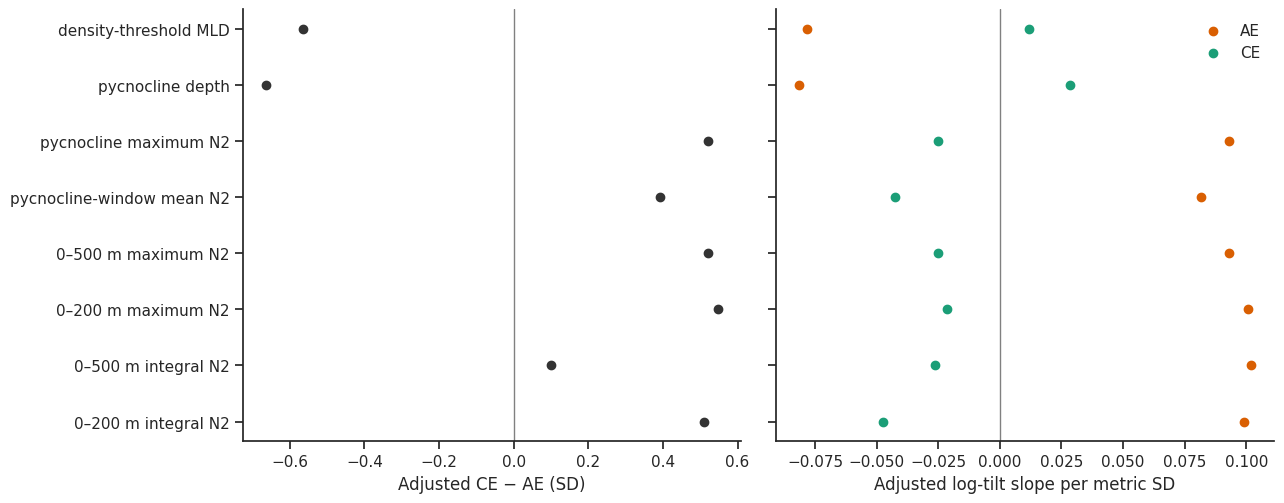

In [8]:
alternative_metrics = {
    '0–200 m integral N2': 'N2_200m_integral_m_s2_core',
    '0–500 m integral N2': 'N2_500m_integral_m_s2_core',
    '0–200 m maximum N2': 'N2_200m_max_s2_core',
    '0–500 m maximum N2': 'N2_500m_max_s2_core',
    'pycnocline-window mean N2': 'N2_pycnocline_mean_s2_core',
    'pycnocline maximum N2': 'N2_pycnocline_max_s2_core',
    'pycnocline depth': 'pycnocline_depth_m_core',
    'density-threshold MLD': 'MLD_density_m_core',
}
metric_eddy = data.groupby(['Cyc', 'Eddy'], as_index=False).agg(
    {'TiltDis': 'median', **{column: 'median' for column in alternative_metrics.values()}})
metric_rows = []
for label, column in alternative_metrics.items():
    ae = metric_eddy.loc[metric_eddy.Cyc.eq('AE'), column].dropna()
    ce = metric_eddy.loc[metric_eddy.Cyc.eq('CE'), column].dropna()
    scale = metric_eddy[column].std()
    metric_rows.append({'metric': label, 'AE_median': ae.median(), 'CE_median': ce.median(),
                        'CE_minus_AE_in_SD': (ce.median() - ae.median()) / scale,
                        'AE_eddies': len(ae), 'CE_eddies': len(ce),
                        'Mann_Whitney_p': mannwhitneyu(ce, ae, alternative='two-sided').pvalue})
metric_raw_table = pd.DataFrame(metric_rows)
display(metric_raw_table)

metric_model_rows = []
for label, column in alternative_metrics.items():
    zcol = f'z_{column}'
    data[zcol] = (data[column] - data[column].mean()) / data[column].std()
    needed = [zcol, 'log_tilt', 'Eddy', 'Cyc', 'lat', 'z_Rc', 'z_h', 'Region', 'Season']
    model_data = data[needed].replace([np.inf, -np.inf], np.nan).dropna()
    polarity_fit = smf.gee(f'{zcol} ~ {rhs}', groups='Eddy', data=model_data,
                              family=sm.families.Gaussian()).fit()
    polarity_term = 'C(Cyc, Treatment(reference="AE"))[T.CE]'
    tilt_formula = (f'log_tilt ~ {zcol} * C(Cyc, Treatment(reference="AE")) + ' +
                    ' + '.join(controls))
    tilt_fit = smf.gee(tilt_formula, groups='Eddy', data=model_data,
                         family=sm.families.Gaussian()).fit()
    interaction = zcol + ':C(Cyc, Treatment(reference="AE"))[T.CE]'
    polarity_ci = polarity_fit.conf_int().loc[polarity_term]
    ae_slope = tilt_fit.params[zcol]
    ae_se = tilt_fit.bse[zcol]
    slope_cov = tilt_fit.cov_params()
    ce_slope = ae_slope + tilt_fit.params[interaction]
    ce_se = np.sqrt(slope_cov.loc[zcol, zcol] + slope_cov.loc[interaction, interaction] +
                    2 * slope_cov.loc[zcol, interaction])
    metric_model_rows.append({
        'metric': label,
        'adjusted_CE_minus_AE_SD': polarity_fit.params[polarity_term],
        'CE_minus_AE_CI_2.5%': polarity_ci.iloc[0],
        'CE_minus_AE_CI_97.5%': polarity_ci.iloc[1],
        'polarity_p': polarity_fit.pvalues[polarity_term],
        'AE_log_tilt_slope_per_SD': ae_slope,
        'AE_slope_CI_2.5%': ae_slope - 1.96 * ae_se,
        'AE_slope_CI_97.5%': ae_slope + 1.96 * ae_se,
        'CE_log_tilt_slope_per_SD': ce_slope,
        'CE_slope_CI_2.5%': ce_slope - 1.96 * ce_se,
        'CE_slope_CI_97.5%': ce_slope + 1.96 * ce_se,
        'polarity_difference_in_slope_p': tilt_fit.pvalues[interaction],
    })
metric_adjusted_table = pd.DataFrame(metric_model_rows)
display(metric_adjusted_table)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.2), sharey=True)
order = metric_adjusted_table.metric.tolist()
axes[0].scatter(metric_adjusted_table.adjusted_CE_minus_AE_SD, order, color='0.2')
axes[0].axvline(0, color='0.5', lw=1); axes[0].set_xlabel('Adjusted CE − AE (SD)')
for cyc, column in [('AE', 'AE_log_tilt_slope_per_SD'), ('CE', 'CE_log_tilt_slope_per_SD')]:
    axes[1].scatter(metric_adjusted_table[column], order, color=PALETTE[cyc], label=cyc)
axes[1].axvline(0, color='0.5', lw=1); axes[1].set_xlabel('Adjusted log-tilt slope per metric SD')
axes[1].legend(frameon=False); sns.despine(); plt.tight_layout()

## Interpretation rules

Use the results in this order:

1. **CEs are more stratified than AEs** is supported only if the CE–AE contrast is positive and its confidence interval excludes zero after adjustment. Report 0–200 m as primary and 0–500 m as sensitivity; disagreement between them is physically informative rather than a failed test.
2. **AEs tilt more than CEs** is confirmed if the adjusted CE coefficient for `log_tilt` is negative.
3. **Stronger stratification accompanies larger tilt** is supported if the continuous between-eddy slope is positive with a confidence interval excluding zero. A positive within-eddy slope supplies stronger temporal evidence, but still does not by itself establish causality.
4. If raw associations disappear after adjustment, the apparent relationship is more consistent with shared latitude, season, geography, size, or bathymetric structure.
5. If AE and CE effects differ, report the polarity-specific estimates rather than a pooled claim.

A polarity contrast in $N^2$ and a relationship between $N^2$ and tilt are distinct questions. Even if both are supported, stratification need not explain the entire AE–CE tilt difference; a mediation analysis would be a separate, explicitly causal step.

In [9]:
# Compact, copyable results bundle for the thesis workflow.
results = {
    'raw_eddy_equal_contrasts': raw_contrasts,
    'adjusted_polarity_contrasts': pd.DataFrame(adjusted_table),
    'raw_stratification_tilt_correlations': pd.DataFrame(correlation_rows),
    'within_between_effects': effects,
    'alternative_metric_raw_contrasts': metric_raw_table,
    'alternative_metric_adjusted_models': metric_adjusted_table,
}
for name, table in results.items():
    print(f'\n{name}')
    display(table)


raw_eddy_equal_contrasts


,outcome,contrast,median_difference,CI_2.5%,CI_97.5%,Mann_Whitney_p,AE_median,CE_median
0,TiltDis,AE - CE,5.368619,4.019718,6.534239,7.771246e-28,22.342611,16.973992
1,N2_200m_1e5,CE - AE,1.938348,1.558733,2.456597,4.363278e-54,2.844200,4.782548
2,N2_500m_1e5,CE - AE,0.298835,0.141656,0.456156,2.337905e-08,2.970358,3.269193



adjusted_polarity_contrasts


,outcome,adjusted_CE_minus_AE,CI_2.5%,CI_97.5%,p,daily_rows
0,log_tilt,-0.259103,-0.298476,-0.219730,4.614826e-38,105621
1,N2_200m_1e5,1.703321,1.581629,1.825012,1.086983e-165,105621
2,N2_500m_1e5,0.178402,0.129304,0.227500,1.065631e-12,105621



raw_stratification_tilt_correlations


...

,depth_m,component,polarity,log_tilt_per_SD_N2,CI_2.5%,CI_97.5%
0,200,within,AE,0.046525,0.023583,0.069468
1,200,within,CE,-0.004138,-0.024431,0.016155
2,200,between,AE,0.084777,0.039930,0.129624
3,200,between,CE,-0.049069,-0.082437,-0.015702
4,500,within,AE,0.063775,0.036259,0.091290
5,500,within,CE,0.008496,-0.009035,0.026026
6,500,between,AE,0.094977,0.050669,0.139285
7,500,between,CE,-0.022682,-0.056735,0.011371



alternative_metric_raw_contrasts


,metric,AE_median,CE_median,CE_minus_AE_in_SD,AE_eddies,CE_eddies,Mann_Whitney_p
0,0–200 m integral N2,0.005329,0.008808,0.594150,1422,1531,7.363424e-53
1,0–500 m integral N2,0.013155,0.014386,0.194219,1422,1531,1.337301e-07
2,0–200 m maximum N2,0.000092,0.000154,0.487863,1422,1531,1.231010e-52
3,0–500 m maximum N2,0.000092,0.000154,0.496471,1422,1531,2.996318e-43
4,pycnocline-window mean N2,0.000050,0.000067,0.439359,1422,1531,1.062332e-24
5,pycnocline maximum N2,0.000092,0.000154,0.496471,1422,1531,2.987362e-43
6,pycnocline depth,116.086297,75.804268,-0.562143,1422,1531,2.542613e-84
7,density-threshold MLD,79.938953,49.103446,-0.583062,1422,1531,1.084988e-58



alternative_metric_adjusted_models


,metric,adjusted_CE_minus_AE_SD,CE_minus_AE_CI_2.5%,CE_minus_AE_CI_97.5%,polarity_p,AE_log_tilt_slope_per_SD,AE_slope_CI_2.5%,AE_slope_CI_97.5%,CE_log_tilt_slope_per_SD,CE_slope_CI_2.5%,CE_slope_CI_97.5%,polarity_difference_in_slope_p
0,0–200 m integral N2,0.509619,0.472614,0.546623,1.832245e-160,0.098970,0.053751,0.144189,-0.047542,-0.081498,-0.013586,4.405003e-12
1,0–500 m integral N2,0.101019,0.068046,0.133993,1.917318e-09,0.102089,0.056462,0.147716,-0.026211,-0.063672,0.011249,1.582705e-10
2,0–200 m maximum N2,0.548608,0.507143,0.590074,2.949726e-148,0.100802,0.053093,0.148512,-0.021615,-0.048384,0.005155,2.075145e-07
3,0–500 m maximum N2,0.519919,0.477733,0.562104,6.540463e-129,0.092886,0.045084,0.140689,-0.024919,-0.050901,0.001063,7.234205e-07
4,pycnocline-window mean N2,0.391748,0.352969,0.430527,2.992269e-87,0.081590,0.036804,0.126376,-0.042532,-0.067959,-0.017106,3.349176e-08
5,pycnocline maximum N2,0.519924,0.477738,0.562110,6.484636e-129,0.092882,0.045079,0.140686,-0.024926,-0.050908,0.001056,7.231012e-07
6,pycnocline depth,-0.664009,-0.712098,-0.615920,2.678519e-161,-0.081573,-0.109521,-0.053625,0.028620,-0.011558,0.068799,1.175035e-06
7,density-threshold MLD,-0.564037,-0.605417,-0.522657,3.082238e-157,-0.078071,-0.108477,-0.047666,0.011766,-0.027409,0.050942,3.284316e-05
